In [15]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.layers import Embedding , LSTM ,Dense
from tensorflow.keras.models import Sequential

In [2]:
train=pd.read_csv('engtamilTrain.csv')
train

,Unnamed: 0,en,ta
0,0,MMA vice president Qazi Hussain Ahmad declared...,MMA கட்சியின் துணைத்தலைவர் க்வாஸி ஹுசேன் அகமத்...
1,1,Information has surfaced in recent years sugge...,சமீபகாலத்தில் சில தகவல்கள் யூலியஸ் ரோசன்பேர்க...
2,2,And Azor begat Sadoc; and Sadoc begat Achim; a...,ஆசோர் சாதோக்கைப் பெற்றான்; சாதோக்கு ஆகீமைப் பெ...
3,3,"She says she knows what is going on, but can d...",என்ன நடக்கிறது என்பது தமக்கு தெரியும் என்றும் ...
4,4,"And be it indeed that I have erred, my error r...","நான் தப்பிநடந்தது மெய்யானாலும், என் தப்பிதம் எ..."
...,...,...,...
166866,166866,"Soon to be released, 'Silandhi' is produced by...",விரைவில் திரைக்கு வர இருக்கும் 'சிலந்தி' படத்த...
166867,166867,"An MHP deputy publicly stated, ""Let them die.""\n",தேசியவாத இயக்கங்களின் கட்சி (MHP) யின் உபதலைவர...
166868,166868,And Aaron shall make an atonement on the horns...,வருஷத்தில் ஒருமுறை ஆரோன் பாவநிவாரணபலியின் இரத்...
166869,166869,"Like the CWC, the UPF is part of the governmen...","இ.தொ.கா. போலவே, மலையக மக்கள் முன்னணியும் அரச..."


In [18]:
english_sentences=train['en']
tamiL_sentences=train['ta']
english_sentences=english_sentences.head(1000)
tamil_sentences=tamil_sentences.head(1000)

In [7]:
!pip install gensim

   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/24.4 MB ? eta -:--:--
    --------------------------------------- 0.5/24.4 MB 762.0 kB/s eta 0:00:32
   - -------------------------------------- 0.8/24.4 MB 763.2 kB/s eta 0:00:31
   - -------------------------------------- 0.8/24.4 MB 763.2 kB/s eta 0:00:31
   - -------------------------------------- 1.0/24.4 MB 762.8 kB/s eta 0:00:31
   -- ------------------------------------- 1.3/24.4 MB 799.2 kB/s eta 0:00:29
   -- ------------------------------------- 1.3/24.4 MB 799.2 kB/s eta 0:00:29
   -- ------------------------------------- 1.6/24.4 MB 830.6 kB/s eta 0:00:28
   --- ------------------------------------ 1.8/24.4 MB 838.9 kB/s eta 0:00:27
   --- -----------

In [8]:
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from matplotlib import pyplot

In [9]:
#Sentence into Tokens 
def sentToken(sentence):
    #define your dataset
    dataset=sentence
    #Convert each sentence to a list of words
    sentences=[sentence.split() for sentence in dataset]
    #print the result
    print(sentences)

    return sentences

In [10]:
engSentence=sentToken(english_sentences)
tamSentence=sentToken(tamil_sentences)

[['MMA', 'vice', 'president', 'Qazi', 'Hussain', 'Ahmad', 'declared', 'last', 'month:', "'We", 'are', 'not', 'extremists.'], ['Information', 'has', 'surfaced', 'in', 'recent', 'years', 'suggesting', 'that', 'Julius', 'Rosenberg', 'was', 'involved', 'in', 'passing', 'some', 'form', 'of', 'intelligence', 'to', 'Soviet', 'officials', 'during', 'the', 'Second', 'World', 'War.'], ['And', 'Azor', 'begat', 'Sadoc;', 'and', 'Sadoc', 'begat', 'Achim;', 'and', 'Achim', 'begat', 'Eliud;'], ['She', 'says', 'she', 'knows', 'what', 'is', 'going', 'on,', 'but', 'can', 'do', 'nothing', 'about', 'it.'], ['And', 'be', 'it', 'indeed', 'that', 'I', 'have', 'erred,', 'my', 'error', 'remains', 'with', 'myself.'], ['Finally,', 'the', 'columnist', 'fails', 'to', 'tell', 'us', 'who', 'among', 'the', 'political', 'leaders', 'of', 'the', 'bourgeoisie,', 'past', 'and', 'present,', 'he', 'counts', 'among', 'the', 'paragons', 'of', 'morality.'], ['These', 'include', 'the', 'British', 'Tamil', 'Forum,', 'La', 'Maiso

In [11]:
#when we have more computation power we can create our own model , when we have less computation power we use Pre-Trained Model


In [13]:
def ownWordModel(langsentence,modelname):
    model=Word2Vec(langsentence,min_count=1)
    print(model)
    #Save Model
    model.save(modelname)
    #fit a 2d PCA model to the vector
    x=model.wv.vectors
    pca=PCA(n_components=2)
    result=pca.fit_transform(x)
    #Create a scatter plot of the project 
    plt.scatter(result[:,0],result[:,1])
    words=list(model.wv.index_to_key)
    for i,word in enumerate (words):
        plt.annotate(word,xy=(result[i,0],result[i,1]))
    plt.show()

Word2Vec<vocab=7300, vector_size=100, alpha=0.025>


C:\Users\USER\anaconda3\envs\aiml\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\anaconda3\envs\aiml\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\anaconda3\envs\aiml\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 130 (\x82) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\anaconda3\envs\aiml\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 159 (\x9f) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


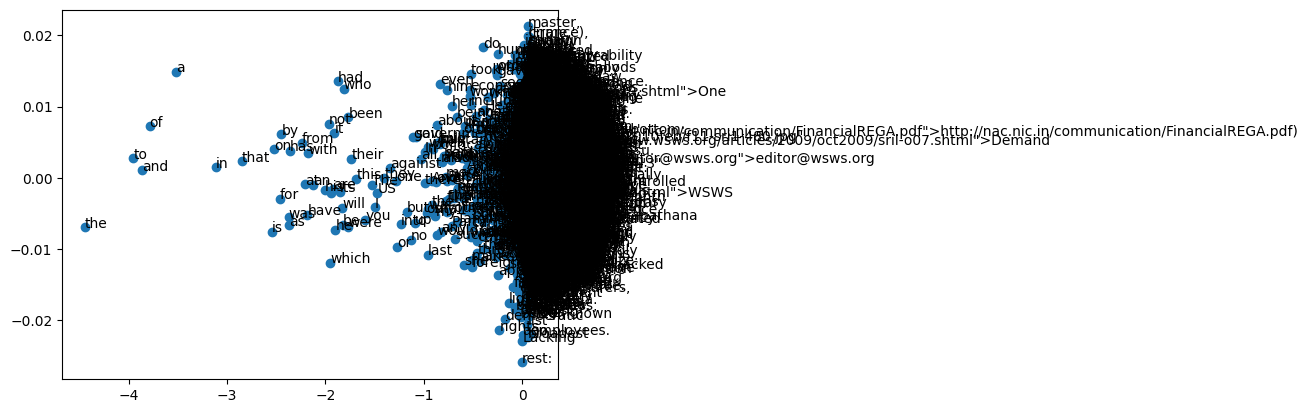

In [16]:
ownWordModel(engSentence,'engmodel.bin')

Word2Vec<vocab=9882, vector_size=100, alpha=0.025>


C:\Users\USER\anaconda3\envs\aiml\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2962 (\N{TAMIL LETTER O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\anaconda3\envs\aiml\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Tamil natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\anaconda3\envs\aiml\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2992 (\N{TAMIL LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\anaconda3\envs\aiml\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3009 (\N{TAMIL VOWEL SIGN U}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\anaconda3\envs\aiml\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2990 (\N{TAMIL LETTER MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figu

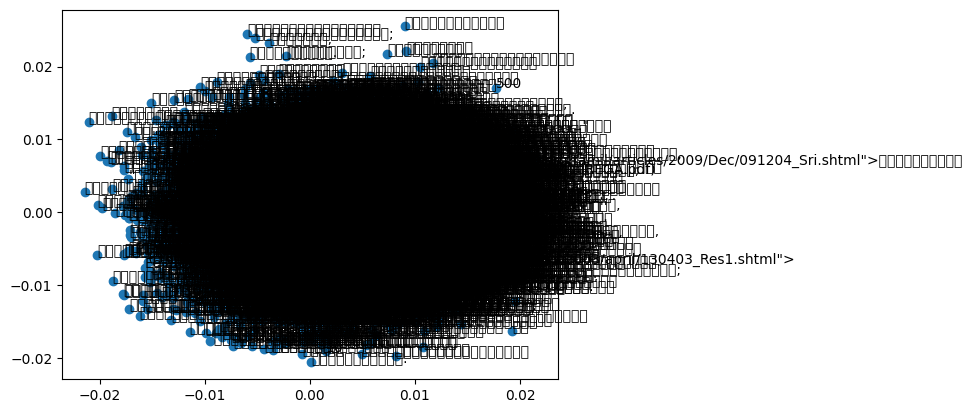

In [17]:
ownWordModel(tamSentence,'tammodel.bin')